# Evaluate

This notebook evaluates the quality of the online alignments in a given experiment directory.

In [1]:
%matplotlib inline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import os.path
from pathlib import Path
import pandas as pd
import pickle
import re
import import_ipynb
import system_utils
import eval_tools

## Calculate Alignment Errors

First we calculate the alignment errors of a given system on all evaluated measures.

**Note:** You can filter evaluation by specific composers or pieces by using the `piece_filter` parameter. For example:
- `piece_filter='bach'` to evaluate only Bach pieces
- `piece_filter='beeth'` to evaluate only Beethoven pieces  
- `piece_filter='mozart'` to evaluate only Mozart pieces
- `piece_filter='rach'` to evaluate only Rachmaninov pieces
- Leave `piece_filter=None` (default) to evaluate all pieces

In [78]:
systems = ['NaivePairwiseDTW','NOA', 'MATCH']
system_idx = 0 # change
modes = ['constant', 'random', 'continuous']
mode_idx = 2 # change
exp_dir = f'experiments/{modes[mode_idx]}/{systems[system_idx]}'
scenarios_dir = f'scenarios/{modes[mode_idx]}'
tsm = True # change
eval_dir = f'eval{"_tsm" if tsm else ""}/' + exp_dir[12:]
lag = 0 # change

# Optional: Filter by composer/piece (e.g., 'bach', 'beeth', 'mozart', 'rach', 'chopin')
# Set to None to evaluate all pieces
piece_filter = "mozart"  # Change this to filter by composer (e.g., piece_filter = 'bach')
eval_tools.calcAlignErrors_batch(exp_dir, scenarios_dir, eval_dir, '', tsm = tsm, lag = lag, piece_filter = piece_filter)

Piece name: mozart
Saved scenario ID: s5
Piece name: mozart
Saved scenario ID: s6
Piece name: mozart
Saved scenario ID: s7
Piece name: mozart
Saved scenario ID: s8
Piece name: mozart
Saved scenario ID: s9
Evaluating 5 scenarios for piece mozart


## Plot Error vs Tolerance

We can visualize the results by plotting the error rate across a range of error tolerances.

In [79]:
def plotErrorVsTolerance(eval_dirs, maxTol, savefile = None, style='bar', bar_tols=[100, 200, 500, 1000, 2000], piece_filter=None):
    '''
    Plots the error rate across a range of error tolerances.
    
    Inputs
    eval_dir: the eval directories to plot
    maxTol: maximum error tolerance to consider (in milliseconds)
    savefile: if specified, will save the figure to the given filepath
    style: 'bar' or 'line'
    tols: list of error tolerances to plot if using 'bar'
    '''
    
    errRates_list = []
    #color=['blue','orange','green','lightgreen','red'] # hard coded for main results figure
    for i, eval_dir in enumerate(eval_dirs):
    
        # load
        with open(f'{eval_dir}/errs.pkl', 'rb') as f:
            d = pickle.load(f)

        # flattened list
        errs = []
        for scenario_id in d:
            errs = np.append(errs, d[scenario_id][0])

        # calculate error rates
        errRates = np.zeros(maxTol+1)
        tols = np.arange(maxTol+1)
        for j in tols:
            errRates[j] = np.mean(np.abs(errs) > j/1000)
        errRates_list.append(errRates)
        
        if style == 'line':
            plt.plot(tols, errRates * 100.0)
        elif style == 'bar':
            bar_width = 0.1
            errs = [errRates[tol] * 100.0 for tol in bar_tols]
            pos = np.arange(len(errs)) + i * bar_width
            # hard code for main results figure
            #plt.bar(pos, errs, width=bar_width, label=os.path.basename(eval_dir), color = color[i])
            plt.bar(pos, errs, width=bar_width, label=os.path.basename(eval_dir))
            plt.xticks([r + bar_width*len(eval_dirs)/2 for r in range(len(bar_tols))], map(str, bar_tols))
        
    plt.ylabel('Error Rate (%)')
    plt.xlabel('Error Tolerance (ms)')
    plt.legend([os.path.basename(eval_dir) for eval_dir in eval_dirs])
    plt.grid(linestyle='--')
    if piece_filter is not None:
        plt.title(f'Error Rate vs Error Tolerance for {piece_filter}')
    else:
        pass
    plt.show()
    if savefile:
        plt.savefig(savefile)

    return errRates_list, tols

Plot the error rate vs error tolerance curve for one system of interest:

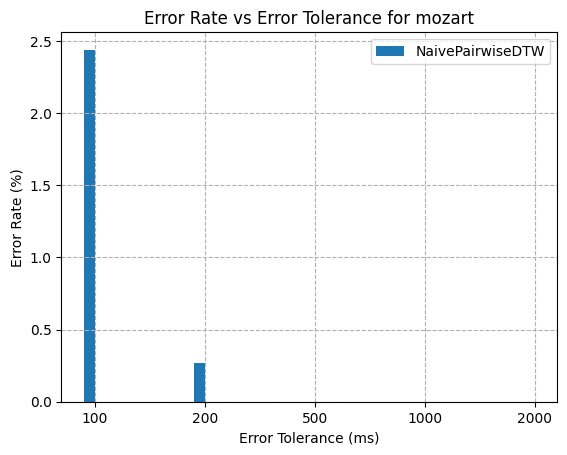

2.4390243902439024
0.27100271002710025
0.0
0.0
0.0


In [80]:
maxTol = 5000 # in milliseconds
tsm = False
eval_dir = f'eval{"_tsm" if tsm else ""}/{modes[mode_idx]}/{systems[system_idx]}'
errRates_list, tols = plotErrorVsTolerance([eval_dir], maxTol, savefile=False, piece_filter=piece_filter)
for i in [100,200,500,1000,2000]:
    print(errRates_list[0][i]*100.0)

Overlay multiple error curves for comparison:

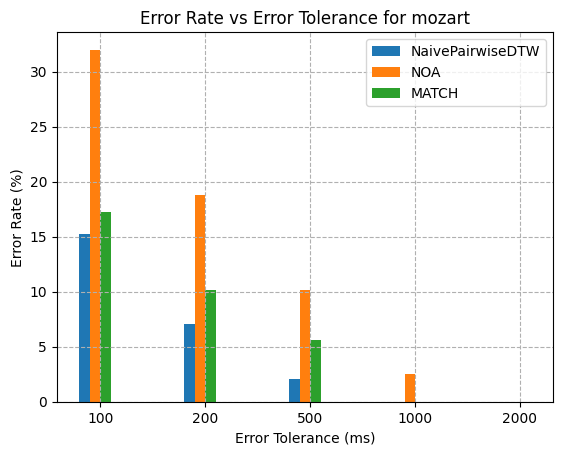

[2.030456852791878, 10.152284263959391, 5.583756345177665]

In [81]:
systems_to_compare = systems
tsm = True
eval_dirs = [f'eval{"_tsm" if tsm else ""}/{modes[mode_idx]}/{s}' for s in systems_to_compare]
errRates_list, tols = plotErrorVsTolerance(eval_dirs, maxTol, bar_tols=[100,200,500,1000,2000], piece_filter=piece_filter)
[errRates_list[i][500]*100.0 for i in range(len(eval_dirs))]